# 📊 Unemployment Rate Forecasting
### World Bank Data 2010–2024 | Regression Analysis
> **Goal:** Predict future unemployment rates using multiple regression models

**Models covered:** Linear · Polynomial (deg 2 & 3) · Exponential · Moving Average

---

In [ ]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 1: Load & Explore Data

In [2]:
# Load dataset
df = pd.read_csv('world_bank_data_2025.csv')

# Rename and clean
df = df[['country_name', 'year', 'Unemployment Rate (%)']].copy()
df.columns = ['country', 'year', 'unemployment']
df = df.dropna(subset=['unemployment'])
df['year'] = df['year'].astype(int)
df['unemployment'] = df['unemployment'].astype(float)

print(f'📊 Dataset shape: {df.shape}')
print(f'🌍 Countries: {df.country.nunique()}')
print(f'📅 Year range: {df.year.min()} – {df.year.max()}')
print(f'\n--- Sample rows ---')
df.head(10)

📊 Dataset shape: (2795, 3)
🌍 Countries: 187
📅 Year range: 2010 – 2024

--- Sample rows ---


,country,year,unemployment
16,Afghanistan,2010,7.753
17,Afghanistan,2011,7.784
18,Afghanistan,2012,7.856
19,Afghanistan,2013,7.930
20,Afghanistan,2014,7.915
21,Afghanistan,2015,9.052
22,Afghanistan,2016,10.133
23,Afghanistan,2017,11.184
24,Afghanistan,2018,11.196
25,Afghanistan,2019,11.185


In [3]:
# Summary statistics
print('=== Global Unemployment Summary ===')
print(df['unemployment'].describe().round(2))
print(f'\nTop 5 highest avg unemployment:')
top5 = df.groupby('country')['unemployment'].mean().nlargest(5)
print(top5.round(2))

=== Global Unemployment Summary ===
count    2795.00
mean        7.84
std         5.96
min         0.10
25%         3.61
50%         5.77
75%        10.73
max        35.36
Name: unemployment, dtype: float64

Top 5 highest avg unemployment:
country
Eswatini              28.21
South Africa          27.96
Djibouti              26.37
West Bank and Gaza    23.04
North Macedonia       22.57
Name: unemployment, dtype: float64


## 🎯 Step 2: Select Country & Configuration

In [4]:
# ============================================
#   🔧 CHANGE THESE PARAMETERS AS YOU LIKE
# ============================================

COUNTRY = 'India'           # Change to any country in the dataset
FORECAST_UP_TO_YEAR = 2027  # Change to any year (e.g. 2026, 2027, 2028, 2030)
MODEL_TYPE = 'linear'       # Options: 'linear', 'poly2', 'poly3', 'exponential', 'moving_avg'

# ============================================

# Filter data
cdata = df[df['country'] == COUNTRY].sort_values('year').reset_index(drop=True)
print(f'✅ Country: {COUNTRY}')
print(f'📅 Data from {cdata.year.min()} to {cdata.year.max()} ({len(cdata)} points)')
print(f'🔮 Forecasting up to: {FORECAST_UP_TO_YEAR}')
print(f'\n--- Historical Data ---')
cdata[['year','unemployment']]

✅ Country: India
📅 Data from 2010 to 2024 (15 points)
🔮 Forecasting up to: 2027

--- Historical Data ---


,year,unemployment
0,2010,7.652
1,2011,7.616
2,2012,7.666
3,2013,7.711
4,2014,7.674
5,2015,7.631
6,2016,7.601
7,2017,7.618
8,2018,7.652
9,2019,6.510


## 🔬 Step 3: Regression Models

In [5]:
def fit_regression(X, y, model_type):
    """
    Fit a regression model.
    Returns: (model, fitted_values, equation_string)
    """
    X2d = X.reshape(-1, 1)
    
    if model_type == 'linear':
        model = LinearRegression()
        model.fit(X2d, y)
        fitted = model.predict(X2d)
        a, b = model.intercept_, model.coef_[0]
        eq = f'y = {a:.3f} + {b:.4f}·x'
        return model, fitted, eq

    elif model_type == 'poly2':
        model = make_pipeline(PolynomialFeatures(2), LinearRegression())
        model.fit(X2d, y)
        fitted = model.predict(X2d)
        coef = model.named_steps['linearregression'].coef_
        intercept = model.named_steps['linearregression'].intercept_
        eq = f'y = {intercept:.3f} + {coef[1]:.4f}·x + {coef[2]:.6f}·x²'
        return model, fitted, eq

    elif model_type == 'poly3':
        model = make_pipeline(PolynomialFeatures(3), LinearRegression())
        model.fit(X2d, y)
        fitted = model.predict(X2d)
        coef = model.named_steps['linearregression'].coef_
        intercept = model.named_steps['linearregression'].intercept_
        eq = (f'y = {intercept:.3f} + {coef[1]:.4f}·x + '
              f'{coef[2]:.5f}·x² + {coef[3]:.7f}·x³')
        return model, fitted, eq

    elif model_type == 'exponential':
        y_safe = np.where(y > 0, y, 0.01)
        log_y = np.log(y_safe)
        lr = LinearRegression()
        lr.fit(X2d, log_y)
        a = np.exp(lr.intercept_)
        b = lr.coef_[0]
        class ExpModel:
            def predict(self, X_in):
                return a * np.exp(b * X_in.ravel())
        model = ExpModel()
        fitted = model.predict(X2d)
        eq = f'y = {a:.3f} · e^({b:.5f}·x)'
        return model, fitted, eq

    elif model_type == 'moving_avg':
        series = pd.Series(y)
        ma = series.rolling(3, min_periods=1).mean().values
        last_n = min(5, len(X))
        trend = LinearRegression()
        trend.fit(X[-last_n:].reshape(-1, 1), y[-last_n:])
        eq = f'3-yr Moving Avg · slope = {trend.coef_[0]:.4f}/yr'
        class MAModel:
            def predict(self, X_in):
                return trend.predict(X_in.reshape(-1, 1))
        return MAModel(), ma, eq


def make_forecast(model, X_train, y_train, last_year, forecast_up_to, rmse):
    """
    Generate forecast with confidence intervals.
    """
    future_years = np.arange(last_year + 1, forecast_up_to + 1, dtype=float)
    if len(future_years) == 0:
        return future_years, np.array([]), np.array([]), np.array([])
    preds = model.predict(future_years.reshape(-1, 1))
    preds = np.maximum(preds, 0)
    ci = rmse * np.array([1.5 + i * 0.3 for i in range(len(future_years))]) * 1.96
    lower = np.maximum(0, preds - ci)
    upper = preds + ci
    return future_years, preds, lower, upper


def evaluate_model(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae


print('✅ All regression functions defined!')

✅ All regression functions defined!


## ▶️ Step 4: Fit Model & Generate Forecast

In [6]:
X = cdata['year'].values.astype(float)
y = cdata['unemployment'].values.astype(float)
last_year = int(X.max())

# Fit the model
model, fitted, equation = fit_regression(X, y, MODEL_TYPE)

# Evaluate
r2, rmse, mae = evaluate_model(y, fitted)

# Forecast
future_years, fc_vals, fc_low, fc_high = make_forecast(
    model, X, y, last_year, FORECAST_UP_TO_YEAR, rmse
)

print('=== Model Results ===')
print(f'  Model     : {MODEL_TYPE}')
print(f'  Equation  : {equation}')
print(f'  R² Score  : {r2:.4f}  (1.0 = perfect fit)')
print(f'  RMSE      : {rmse:.3f}%')
print(f'  MAE       : {mae:.3f}%')
print(f'  Forecasting {len(future_years)} year(s): {int(last_year+1)} → {FORECAST_UP_TO_YEAR}')

# Print forecast values
print(f'\n=== Forecast for {COUNTRY} ===')
for yr, pred, lo, hi in zip(future_years, fc_vals, fc_low, fc_high):
    print(f'  {int(yr)}: {pred:.2f}%  (95% CI: {lo:.2f}% – {hi:.2f}%)')

=== Model Results ===
  Model     : linear
  Equation  : y = 482.244 + -0.2357·x
  R² Score  : 0.6130  (1.0 = perfect fit)
  RMSE      : 0.809%
  MAE       : 0.675%
  Forecasting 3 year(s): 2025 → 2027

=== Forecast for India ===
  2025: 4.97%  (95% CI: 2.59% – 7.34%)
  2026: 4.73%  (95% CI: 1.88% – 7.58%)
  2027: 4.49%  (95% CI: 1.16% – 7.82%)


## 📈 Step 5: Visualization

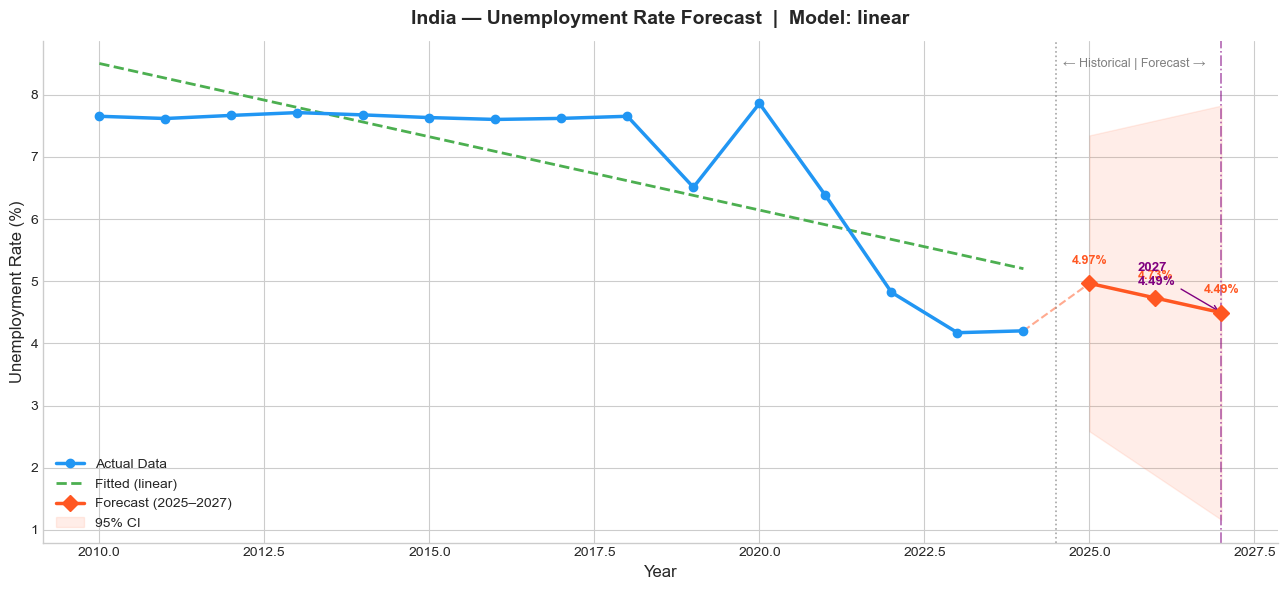

📁 Chart saved as unemployment_forecast.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

# Historical data
ax.plot(X, y, 'o-', color='#2196F3', lw=2.5, ms=6, zorder=4, label='Actual Data')

# Fitted trend
ax.plot(X, fitted, '--', color='#4CAF50', lw=2, zorder=3, label=f'Fitted ({MODEL_TYPE})')

# Forecast
if len(future_years) > 0:
    ax.plot([last_year, future_years[0]], [y[-1], fc_vals[0]],
            '--', color='#FF5722', lw=1.5, alpha=0.5)
    ax.plot(future_years, fc_vals, 'D-', color='#FF5722', lw=2.5, ms=8,
            zorder=5, label=f'Forecast ({int(last_year+1)}–{FORECAST_UP_TO_YEAR})')
    ax.fill_between(future_years, fc_low, fc_high,
                    color='#FF5722', alpha=0.1, label='95% CI')
    # Annotate forecast
    for yr, val in zip(future_years, fc_vals):
        ax.annotate(f'{val:.2f}%', xy=(yr, val), xytext=(0, 14),
                    textcoords='offset points', ha='center', fontsize=9,
                    color='#FF5722', fontweight='bold')

# Divider
ax.axvline(x=last_year + 0.5, color='gray', ls=':', lw=1.2, alpha=0.7)
ylim = ax.get_ylim()
ax.text(last_year + 0.6, ylim[1] * 0.97, '← Historical | Forecast →',
        fontsize=9, color='gray', va='top')

# Highlight 2027
if 2027 in future_years:
    idx = list(future_years).index(2027)
    ax.axvline(x=2027, color='purple', ls='-.', lw=1.2, alpha=0.6)
    ax.annotate(f'2027\n{fc_vals[idx]:.2f}%', xy=(2027, fc_vals[idx]),
                xytext=(-60, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='purple'),
                fontsize=9.5, color='purple', fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title(f'{COUNTRY} — Unemployment Rate Forecast  |  Model: {MODEL_TYPE}',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(framealpha=0.9, fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('unemployment_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Chart saved as unemployment_forecast.png')

## 🔍 Step 6: Residual Analysis

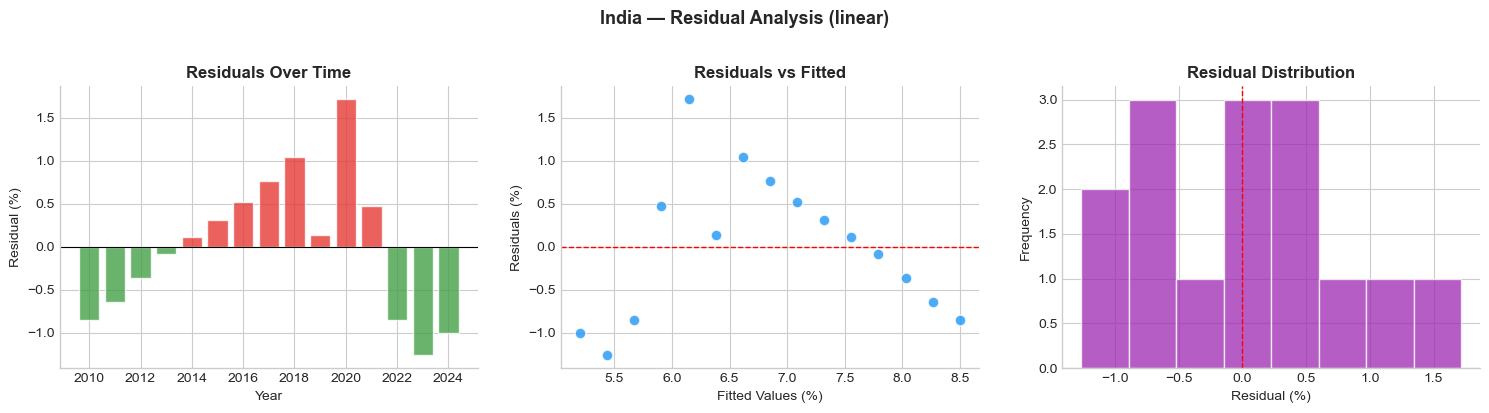

In [8]:
residuals = y - fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
colors = ['#E53935' if r > 0 else '#43A047' for r in residuals]
axes[0].bar(X, residuals, color=colors, alpha=0.8, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Residuals Over Time', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Residual (%)')
axes[0].spines[['top','right']].set_visible(False)

# Residuals vs fitted
axes[1].scatter(fitted, residuals, color='#2196F3', alpha=0.8, s=60, edgecolors='white')
axes[1].axhline(0, color='red', ls='--', lw=1)
axes[1].set_title('Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted Values (%)'); axes[1].set_ylabel('Residuals (%)')
axes[1].spines[['top','right']].set_visible(False)

# Histogram of residuals
axes[2].hist(residuals, bins=8, color='#9C27B0', alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', ls='--', lw=1)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual (%)'); axes[2].set_ylabel('Frequency')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle(f'{COUNTRY} — Residual Analysis ({MODEL_TYPE})', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 7: Compare All Models

In [9]:
all_models = {
    'Linear'       : 'linear',
    'Polynomial-2' : 'poly2',
    'Polynomial-3' : 'poly3',
    'Exponential'  : 'exponential',
    'Moving Avg'   : 'moving_avg'
}

comparison = []
for name, mtype in all_models.items():
    try:
        m, f_vals, eq = fit_regression(X, y, mtype)
        r2_m, rmse_m, mae_m = evaluate_model(y, f_vals)
        fy, fv, fl, fh = make_forecast(m, X, y, last_year, FORECAST_UP_TO_YEAR, rmse_m)
        pred_target = round(fv[-1], 2) if len(fv) > 0 else None
        pred_2027 = None
        if 2027 in fy:
            pred_2027 = round(fv[list(fy).index(2027)], 2)
        comparison.append({
            'Model': name, 'R²': round(r2_m, 4),
            'RMSE (%)': round(rmse_m, 3), 'MAE (%)': round(mae_m, 3),
            f'{FORECAST_UP_TO_YEAR} Forecast (%)': pred_target,
            '2027 Forecast (%)': pred_2027
        })
    except Exception as e:
        print(f'  ⚠️  {name} failed: {e}')

comp_df = pd.DataFrame(comparison)
best = comp_df.loc[comp_df['R²'].idxmax(), 'Model']
print(f'🏆 Best model by R²: {best}\n')
comp_df

🏆 Best model by R²: Polynomial-3



,Model,R²,RMSE (%),MAE (%),2027 Forecast (%)
0,Linear,0.6130,0.809,0.675,4.49
1,Polynomial-2,0.8694,0.470,0.354,1.26
2,Polynomial-3,0.8887,0.434,0.284,0.00
3,Exponential,0.5272,0.894,0.769,4.50
4,Moving Avg,0.8259,0.543,0.312,0.73


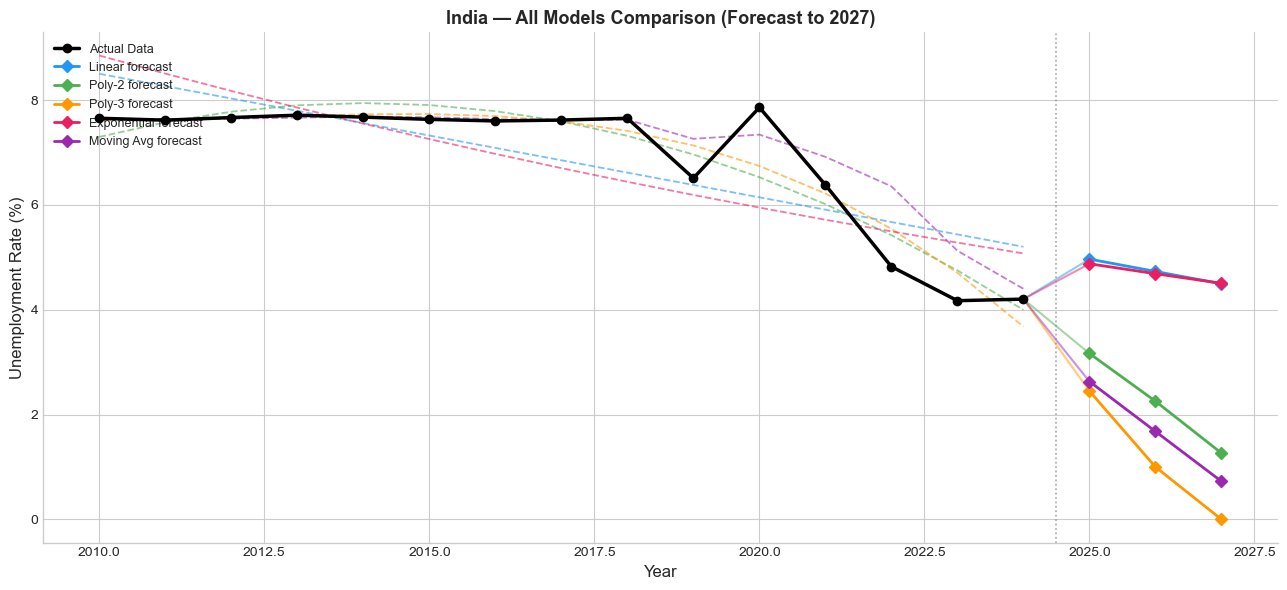

In [10]:
# Plot all model forecasts on one chart
fig, ax = plt.subplots(figsize=(13, 6))

colors_map = {
    'linear': '#2196F3', 'poly2': '#4CAF50', 'poly3': '#FF9800',
    'exponential': '#E91E63', 'moving_avg': '#9C27B0'
}
labels_map = {
    'linear': 'Linear', 'poly2': 'Poly-2', 'poly3': 'Poly-3',
    'exponential': 'Exponential', 'moving_avg': 'Moving Avg'
}

# Actual data
ax.plot(X, y, 'ko-', lw=2.5, ms=6, zorder=6, label='Actual Data')

for mtype, color in colors_map.items():
    try:
        m, f_vals, _ = fit_regression(X, y, mtype)
        _, rmse_m, _ = evaluate_model(y, f_vals)
        fy, fv, fl, fh = make_forecast(m, X, y, last_year, FORECAST_UP_TO_YEAR, rmse_m)
        # Fitted
        ax.plot(X, f_vals, '--', color=color, lw=1.3, alpha=0.6)
        # Forecast
        if len(fy) > 0:
            ax.plot([last_year, fy[0]], [y[-1], fv[0]], '-', color=color, lw=1.5, alpha=0.5)
            ax.plot(fy, fv, 'D-', color=color, lw=2, ms=6,
                    label=f'{labels_map[mtype]} forecast')
    except:
        pass

ax.axvline(x=last_year + 0.5, color='gray', ls=':', lw=1.2, alpha=0.7)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title(f'{COUNTRY} — All Models Comparison (Forecast to {FORECAST_UP_TO_YEAR})',
             fontsize=13, fontweight='bold')
ax.legend(framealpha=0.9, fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 📋 Step 8: Forecast Table

In [11]:
# Run selected model and print detailed forecast
model, fitted, equation = fit_regression(X, y, MODEL_TYPE)
r2, rmse, mae = evaluate_model(y, fitted)
future_years, fc_vals, fc_low, fc_high = make_forecast(
    model, X, y, last_year, FORECAST_UP_TO_YEAR, rmse
)

forecast_df = pd.DataFrame({
    'Year': future_years.astype(int),
    'Predicted (%)': np.round(fc_vals, 3),
    'Lower 95% CI (%)': np.round(fc_low, 3),
    'Upper 95% CI (%)': np.round(fc_high, 3),
    'YoY Change (%)': np.round(
        np.concatenate([[fc_vals[0] - y[-1]], np.diff(fc_vals)]), 3
    )
})
forecast_df['Trend'] = forecast_df['YoY Change (%)'].apply(
    lambda x: '📈 Rising' if x > 0.2 else ('📉 Falling' if x < -0.2 else '➡️ Stable')
)

print(f'=== {COUNTRY} Forecast Summary | Model: {MODEL_TYPE} ===')
print(f'  R² = {r2:.4f} | RMSE = {rmse:.3f}% | MAE = {mae:.3f}%')
print(f'  Equation: {equation}\n')
forecast_df

=== India Forecast Summary | Model: linear ===
  R² = 0.6130 | RMSE = 0.809% | MAE = 0.675%
  Equation: y = 482.244 + -0.2357·x



,Year,Predicted (%),Lower 95% CI (%),Upper 95% CI (%),YoY Change (%),Trend
0,2025,4.966,2.587,7.344,0.764,📈 Rising
1,2026,4.730,1.875,7.584,-0.236,📉 Falling
2,2027,4.494,1.164,7.824,-0.236,📉 Falling


## ✅ Summary

| Step | Done |
|------|------|
| Load & explore World Bank data | ✅ |
| Filter by country | ✅ |
| Fit 5 regression models | ✅ |
| Visualize with confidence intervals | ✅ |
| Residual analysis | ✅ |
| Model comparison | ✅ |
| Detailed forecast table | ✅ |

### 🚀 To run as Streamlit app:
```bash
streamlit run app.py
```
> Change `COUNTRY`, `FORECAST_UP_TO_YEAR`, and `MODEL_TYPE` in Step 2 to explore any country!